In [10]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [11]:
df = pd.read_csv("burst_anomaly_table.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["hour"] = pd.to_numeric(df["hour"], errors="coerce").fillna(0).astype(int)
df["datetime"] = df["date"] + pd.to_timedelta(df["hour"], unit="h")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

In [12]:
def run_cusum_eval(df, k, h):
    temp = df.copy()
    temp["cusum_flag"] = 0
    
    for t, group in temp.groupby("call_type_filtered"):
        vals = group["total_calls"].values
        mean_val = np.mean(vals)
        std_val = np.std(vals)
        pos = 0
        neg = 0
        flags = np.zeros(len(vals), dtype=int)

        for i in range(1, len(vals)):
            x = vals[i] - mean_val
            pos = max(0, pos + x - k*std_val)
            neg = min(0, neg + x + k*std_val)

            if pos > h*std_val or abs(neg) > h*std_val:
                flags[i] = 1

        temp.loc[group.index, "cusum_flag"] = flags

    p = precision_score(temp["is_anomaly"], temp["cusum_flag"])
    r = recall_score(temp["is_anomaly"], temp["cusum_flag"])
    f = f1_score(temp["is_anomaly"], temp["cusum_flag"])
    
    return p, r, f


k_values = [1.0, 1.3, 1.5, 1.7, 2.0, 3.0]
h_values = [5, 6, 7, 8, 9, 10]

results = []
for k in k_values:
    for h in h_values:
        p, r, f = run_cusum_eval(df, k, h)
        results.append((k, h, p, r, f))
        print(f"k={k}, h={h} → Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")

results_sorted = sorted(results, key=lambda x: x[4], reverse=True)
print("Top Results ordered by F1 score")
for row in results_sorted[:10]:
    print(row)

k=1.0, h=5 → Precision=0.0060, Recall=0.6663, F1=0.0118
k=1.0, h=6 → Precision=0.0060, Recall=0.6432, F1=0.0118
k=1.0, h=7 → Precision=0.0060, Recall=0.6256, F1=0.0119
k=1.0, h=8 → Precision=0.0060, Recall=0.6100, F1=0.0120
k=1.0, h=9 → Precision=0.0061, Recall=0.5920, F1=0.0120
k=1.0, h=10 → Precision=0.0061, Recall=0.5778, F1=0.0121
k=1.3, h=5 → Precision=0.0082, Recall=0.4650, F1=0.0161
k=1.3, h=6 → Precision=0.0082, Recall=0.4490, F1=0.0162
k=1.3, h=7 → Precision=0.0084, Recall=0.4371, F1=0.0164
k=1.3, h=8 → Precision=0.0084, Recall=0.4244, F1=0.0165
k=1.3, h=9 → Precision=0.0084, Recall=0.4099, F1=0.0165
k=1.3, h=10 → Precision=0.0084, Recall=0.3968, F1=0.0165
k=1.5, h=5 → Precision=0.0105, Recall=0.3869, F1=0.0204
k=1.5, h=6 → Precision=0.0106, Recall=0.3711, F1=0.0206
k=1.5, h=7 → Precision=0.0107, Recall=0.3579, F1=0.0207
k=1.5, h=8 → Precision=0.0107, Recall=0.3442, F1=0.0207
k=1.5, h=9 → Precision=0.0107, Recall=0.3323, F1=0.0208
k=1.5, h=10 → Precision=0.0107, Recall=0.3179,

In [13]:
def cusum_detector(series, k=1.0, h=5.0):
    series = series.values
    mean_val = np.mean(series)
    std_val = np.std(series)

    if std_val == 0 or np.isnan(std_val):
        return pd.DataFrame({
            "cusum_pos": np.zeros(len(series)),
            "cusum_neg": np.zeros(len(series)),
            "cusum_flag": np.zeros(len(series), dtype=int),})

    pos = np.zeros(len(series))
    neg = np.zeros(len(series))
    flag = np.zeros(len(series), dtype=int)

    for i in range(1, len(series)):
        x = series[i] - mean_val
        pos[i] = max(0, pos[i-1] + x - k * std_val)
        neg[i] = min(0, neg[i-1] + x + k * std_val)

        if pos[i] > h * std_val or abs(neg[i]) > h * std_val:
            flag[i] = 1

    return pd.DataFrame({"cusum_pos": pos, "cusum_neg": neg, "cusum_flag": flag})
    
####
df = df.sort_values(["call_type_filtered", "datetime"]).reset_index(drop=True)

cusum_results = (
    df.groupby("call_type_filtered", group_keys=False)["total_calls"]
      .apply(lambda s: cusum_detector(s, k=1.5, h=6.0))
)

cusum_results = cusum_results.reset_index(drop=True)

df = pd.concat([df, cusum_results], axis=1)


###
df["rolling_mean"] = (df.groupby("call_type_filtered")["total_calls"].transform(lambda s: s.rolling(24, min_periods=1).mean()))
df["MonthLabel"] = df["datetime"].dt.strftime("%b %Y")
df["t_hours"] = (df["datetime"] - df.groupby("MonthLabel")["datetime"].transform("min")).dt.total_seconds() / 3600

###
types_sorted = sorted(df["call_type_filtered"].unique())
palette = px.colors.qualitative.Set2
color_map = {t: palette[i % len(palette)] for i, t in enumerate(types_sorted)}
months = sorted(df["MonthLabel"].unique(), key=lambda x: pd.to_datetime(x))

frames = []
for m in months:
    dm = df[df["MonthLabel"] == m]
    traces = []
    for t in types_sorted:
        dmt = dm[dm["call_type_filtered"] == t].sort_values("t_hours")

        traces.append(go.Scatter(
            x=dmt["t_hours"], y=dmt["rolling_mean"],
            mode="lines", line=dict(color=color_map[t], width=2),
            name=f"{t} — Trend", showlegend=(m == months[0])))

        stress = dmt[dmt["cusum_flag"] == 1]
        if not stress.empty:
            traces.append(go.Scatter(
                x=stress["t_hours"], y=stress["rolling_mean"],
                mode="markers", marker=dict(size=8, color="orange", symbol="circle"),
                name=f"{t} — CUSUM Alert", showlegend=(m == months[0])))

        bursts = dmt[dmt["is_anomaly"] == 1]
        if not bursts.empty:
            traces.append(go.Scatter(
                x=bursts["t_hours"], y=bursts["rolling_mean"],
                mode="markers", marker=dict(size=10, color="red", symbol="x"),
                name=f"{t} — Confirmed Burst", showlegend=(m == months[0])))

    frames.append(go.Frame(name=m, data=traces))


###
init_month = months[0]
d0 = df[df["MonthLabel"] == init_month]

init_traces = []
for t in types_sorted:
    d0t = d0[d0["call_type_filtered"] == t].sort_values("t_hours")

    init_traces.append(go.Scatter(
        x=d0t["t_hours"], y=d0t["rolling_mean"],
        mode="lines", name=f"{t} — Trend", line=dict(color=color_map[t])))

    stress = d0t[d0t["cusum_flag"] == 1]
    if not stress.empty:
        init_traces.append(go.Scatter(
            x=stress["t_hours"], y=stress["rolling_mean"],
            mode="markers", marker=dict(size=8, color="orange", symbol="circle"),
            name=f"{t} — CUSUM Alert"))

    bursts = d0t[d0t["is_anomaly"] == 1]
    if not bursts.empty:
        init_traces.append(go.Scatter(
            x=bursts["t_hours"], y=bursts["rolling_mean"],
            mode="markers", marker=dict(size=10, color="red", symbol="x"),
            name=f"{t} — Confirmed Burst"))

layout = go.Layout(
    title="Animated CUSUM vs Confirmed Bursts",
    template="plotly_white",
    height=800,
    xaxis=dict(title="Hours Since Month Start"),
    yaxis=dict(title="Rolling Mean Calls"),
    updatemenus=[{
        "type": "buttons", "direction": "left", "x": 0.05, "y": 1.15,
        "buttons": [
            {"label": "▶ Play", "method": "animate", 
             "args": [None, {"frame": {"duration": 500, "redraw": True}}]},
            {"label": "⏸ Pause", "method": "animate",
             "args": [[None], {"mode": "immediate", "frame": {"duration": 0}}]}]}],
    sliders=[{
        "active": 0, "y": -0.05, "pad": {"t": 50}, 
        "currentvalue": {"prefix": "Month: "},
        "steps": [{"args": [[m], {"frame": {"duration": 0, "redraw": True}}],
                   "label": m, "method": "animate"} for m in months],}])

#fig = go.Figure(data=init_traces, layout=layout, frames=frames)
#fig.show()


###
val = df.copy()
val["cusum_flag"] = val["cusum_flag"].astype(int)
val["is_anomaly"] = val["is_anomaly"].astype(int)

precision = precision_score(val["is_anomaly"], val["cusum_flag"])
recall = recall_score(val["is_anomaly"], val["cusum_flag"])
f1 = f1_score(val["is_anomaly"], val["cusum_flag"])

print("\n=== CUSUM VALIDATION ===")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

cm = confusion_matrix(val["is_anomaly"], val["cusum_flag"])
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=["Actual Normal","Actual Burst"], columns=["Pred Normal","Pred Burst"]))


=== CUSUM VALIDATION ===
Precision: 0.011
Recall:    0.371
F1 Score:  0.021

Confusion Matrix:
               Pred Normal  Pred Burst
Actual Normal      1756889      235110
Actual Burst          4263        2516


We selected these k and h values because they produced the best trade-off between catching true anomalies and avoiding excessive false alarms in testing. The chosen thresholds are slightly conservative, allowing the system to detect meaningful bursts while keeping early-warning noise at a manageable level.

This visualization shows how 911 call activity changes over time and highlights unusual spikes using the CUSUM early-warning algorithm. Each colored line represents the normal 24-hour rolling trend for one call type. Orange circles mark moments where CUSUM detects unusual upward movement which are early warnings indicating that call volume is starting to rise beyond what is normally expected. Red “X” markers represent confirmed anomalies based on the ground-truth labels in the dataset. When orange markers appear shortly before red ones, it means CUSUM is successfully identifying the beginning of abnormal activity. A few scattered orange points are expected and not necessarily meaningful, but long clusters or sustained periods of orange indicate a real surge in calls. Because each call type has its own baseline behavior, trends should be interpreted relative to the history of the same call type, not compared across different types. The animation simply progresses month by month so you can see how patterns evolve, when bursts emerge, and how early the system detects them.

/var/folders/ts/7tn82kv17mjbx_0d7r4ty0bh0000gn/T/ipykernel_8905/3848766691.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_vis = vis1_df.groupby("call_type", group_keys=False).apply(compute_cusum)


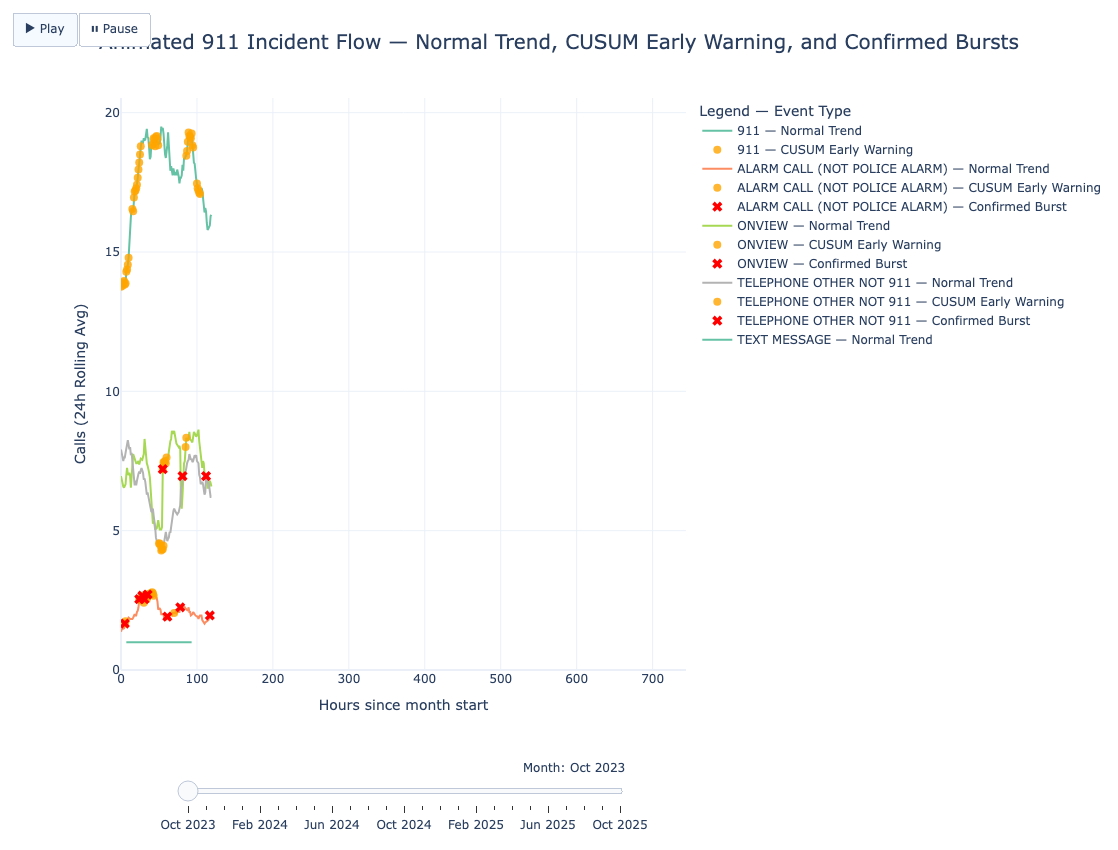

In [1]:
import os
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

path = os.path.join(os.getcwd(), "vis1_df.csv")
if not os.path.exists(path):
    raise FileNotFoundError("vis1_df.csv not found in current directory.")
vis1_df = pd.read_csv(path)


for col in ["datetime", "event_hour", "date"]:
    if col in vis1_df.columns:
        vis1_df[col] = pd.to_datetime(vis1_df[col], errors="coerce", utc=False)


if "hour" in vis1_df.columns:
    vis1_df["hour"] = pd.to_numeric(vis1_df["hour"], errors="coerce").round().astype("Int64")
    vis1_df.loc[vis1_df["hour"].notna(), "hour"] = vis1_df.loc[vis1_df["hour"].notna(), "hour"].clip(0, 23)

datetime_col = None


if "datetime" in vis1_df.columns and pd.api.types.is_datetime64_any_dtype(vis1_df["datetime"]):
    datetime_col = vis1_df["datetime"]

elif "event_hour" in vis1_df.columns and pd.api.types.is_datetime64_any_dtype(vis1_df["event_hour"]):
    datetime_col = vis1_df["event_hour"]


elif ("date" in vis1_df.columns and pd.api.types.is_datetime64_any_dtype(vis1_df["date"])) and ("hour" in vis1_df.columns):
    hour_fill = vis1_df["hour"].fillna(0).astype("int32")
    datetime_col = vis1_df["date"] + pd.to_timedelta(hour_fill, unit="h")

elif "date" in vis1_df.columns:
    if vis1_df["date"].notna().any():
        datetime_col = vis1_df["date"]


vis1_df["datetime"] = pd.to_datetime(datetime_col, errors="coerce")
before = len(vis1_df)
vis1_df = vis1_df.dropna(subset=["datetime"])
after = len(vis1_df)
#if after == 0:
#    raise TypeError("All rows became NaT after datetime parsing. Inspect your CSV date/hour values.")
#if after < before:
#    print(f"ℹ️ Dropped {before - after} rows with invalid timestamps; proceeding with {after} rows.")

required = {"call_type", "total_calls"}
#missing = [c for c in required if c not in vis1_df.columns]
#if missing:
#    raise KeyError(f"Missing required columns in vis1_df: {missing}")


vis1_df["total_calls"] = pd.to_numeric(vis1_df["total_calls"], errors="coerce").fillna(0)

# Optional: ensure is_anomaly exists (ok if missing)
#if "is_anomaly" in vis1_df.columns:
#    vis1_df["is_anomaly"] = pd.to_numeric(vis1_df["is_anomaly"], errors="coerce").fillna(0).astype(int)

vis1_df["MonthLabel"] = vis1_df["datetime"].dt.strftime("%b %Y")
vis1_df = vis1_df.sort_values(["MonthLabel", "datetime"])
vis1_df["t_hours"] = ((vis1_df["datetime"] - vis1_df.groupby("MonthLabel")["datetime"].transform("min")).dt.total_seconds() / 3600)

def compute_cusum(df, value_col="total_calls"):
    mean_val = df[value_col].mean()
    std_val = df[value_col].std()
    if pd.isna(std_val) or std_val == 0:
        df["cusum_pos"] = 0.0
        df["cusum_neg"] = 0.0
        df["cusum_flag"] = 0
        return df
    k = 0.65 * std_val
    h = 3.0 * std_val
    pos = np.zeros(len(df))
    neg = np.zeros(len(df))
    flag = np.zeros(len(df))
    for i in range(1, len(df)):
        x = df[value_col].iloc[i] - mean_val
        pos[i] = max(0, pos[i-1] + x - k)
        neg[i] = min(0, neg[i-1] + x + k)
        if pos[i] > h or abs(neg[i]) > h:
            flag[i] = 1
    df["cusum_pos"] = pos
    df["cusum_neg"] = neg
    df["cusum_flag"] = flag
    return df

hourly_vis = vis1_df.groupby("call_type", group_keys=False).apply(compute_cusum)


hourly_vis["rolling_mean"] = (
    hourly_vis.groupby("call_type")["total_calls"]
    .transform(lambda s: s.rolling(24, min_periods=1).mean())
)

types_sorted = sorted(hourly_vis["call_type"].unique())
palette = px.colors.qualitative.Set2
color_map = {t: palette[i % len(palette)] for i, t in enumerate(types_sorted)}
month_labels = sorted(hourly_vis["MonthLabel"].unique(), key=lambda x: pd.to_datetime(x))

frames = []
for m in month_labels:
    d_m = hourly_vis[hourly_vis["MonthLabel"] == m]
    traces = []
    for t in types_sorted:
        d_mt = d_m[d_m["call_type"] == t].sort_values("t_hours")
        traces.append(go.Scatter(
            x=d_mt["t_hours"], y=d_mt["rolling_mean"], mode="lines",
            name=f"{t} — Normal Trend",
            line=dict(color=color_map[t], width=2),
            showlegend=(m == month_labels[0])
        ))
        stress = d_mt[d_mt["cusum_flag"] == 1]
        if not stress.empty:
            traces.append(go.Scatter(
                x=stress["t_hours"], y=stress["rolling_mean"], mode="markers",
                marker=dict(size=8, color="orange", opacity=0.8, symbol="circle"),
                name=f"{t} — CUSUM Early Warning",
                showlegend=(m == month_labels[0])
            ))
        if "is_anomaly" in d_mt.columns:
            bursts = d_mt[d_mt["is_anomaly"] == 1]
            if not bursts.empty:
                traces.append(go.Scatter(
                    x=bursts["t_hours"], y=bursts["rolling_mean"], mode="markers",
                    marker=dict(color="red", size=9, symbol="x"),
                    name=f"{t} — Confirmed Burst",
                    showlegend=(m == month_labels[0])
                ))
    frames.append(go.Frame(name=m, data=traces))


init_month = month_labels[0]
d0 = hourly_vis[hourly_vis["MonthLabel"] == init_month]
init_traces = []
for t in types_sorted:
    d0_t = d0[d0["call_type"] == t].sort_values("t_hours")
    init_traces.append(go.Scatter(
        x=d0_t["t_hours"], y=d0_t["rolling_mean"], mode="lines",
        name=f"{t} — Normal Trend", line=dict(color=color_map[t]), showlegend=True
    ))
    stress = d0_t[d0_t["cusum_flag"] == 1]
    if not stress.empty:
        init_traces.append(go.Scatter(
            x=stress["t_hours"], y=stress["rolling_mean"], mode="markers",
            marker=dict(size=8, color="orange", opacity=0.8, symbol="circle"),
            name=f"{t} — CUSUM Early Warning", showlegend=True
        ))
    if "is_anomaly" in d0_t.columns:
        bursts = d0_t[d0_t["is_anomaly"] == 1]
        if not bursts.empty:
            init_traces.append(go.Scatter(
                x=bursts["t_hours"], y=bursts["rolling_mean"], mode="markers",
                marker=dict(color="red", size=9, symbol="x"),
                name=f"{t} — Confirmed Burst", showlegend=True
            ))

layout = go.Layout(
    title=dict(text="Animated 911 Incident Flow — Normal Trend, CUSUM Early Warning, and Confirmed Bursts",
               x=0.5, font=dict(size=20)),
    template="plotly_white",
    hovermode="x unified",
    xaxis=dict(title="Hours since month start", range=[0, 31*24]),
    yaxis=dict(title="Calls (24h Rolling Avg)", rangemode="tozero"),
    height=850,
    legend=dict(title="Legend — Event Type", yanchor="top", y=1, xanchor="left", x=1.02,
                bgcolor="rgba(255,255,255,0.8)"),
    updatemenus=[{
        "type": "buttons", "direction": "left", "x": 0.05, "y": 1.15,
        "buttons": [
            {"label":"▶ Play","method":"animate",
             "args":[None, {"frame":{"duration":700,"redraw":True}, "fromcurrent":True}]},
            {"label":"⏸ Pause","method":"animate",
             "args":[[None], {"mode":"immediate","frame":{"duration":0,"redraw":False}}]}
        ],
    }],
    sliders=[{
        "active": 0, "y": -0.08, "x": 0.1, "len": 0.8, "pad": {"b": 10, "t": 40},
        "currentvalue": {"visible": True, "prefix": "Month: ", "xanchor": "right", "offset": 10},
        "steps": [{"args": [[m], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                   "label": m, "method": "animate"} for m in month_labels],
    }],
)

fig = go.Figure(data=init_traces, layout=layout, frames=frames)
fig.update_layout(margin=dict(l=60, r=280, t=80, b=60))
fig.show()


In [2]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cusum_val_df = hourly_vis[["call_type", "cusum_flag", "is_anomaly"]].copy()

cusum_val_df["cusum_flag"] = cusum_val_df["cusum_flag"].fillna(0).astype(int)
cusum_val_df["is_anomaly"] = cusum_val_df["is_anomaly"].fillna(0).astype(int)

precision = precision_score(cusum_val_df["is_anomaly"], cusum_val_df["cusum_flag"])
recall = recall_score(cusum_val_df["is_anomaly"], cusum_val_df["cusum_flag"])
f1 = f1_score(cusum_val_df["is_anomaly"], cusum_val_df["cusum_flag"])

print("=== CUSUM Model Validation ===")
print(f"Precision (how many detected were true bursts): {precision:.3f}")
print(f"Recall (how many true bursts were detected):  {recall:.3f}")
print(f"F1 Score (balance of both):                   {f1:.3f}")

cm = confusion_matrix(cusum_val_df["is_anomaly"], cusum_val_df["cusum_flag"])
cm_df = pd.DataFrame(cm, index=["Actual Normal", "Actual Burst"], columns=["Pred Normal", "Pred Burst"])
print("\nConfusion Matrix:")
print(cm_df)

summary = (
    cusum_val_df.groupby("call_type")[["cusum_flag", "is_anomaly"]]
    .sum()
    .rename(columns={"cusum_flag": "CUSUM_Detections", "is_anomaly": "True_Bursts"})
)
summary["Precision"] = cusum_val_df.groupby("call_type").apply(lambda g: precision_score(g["is_anomaly"], g["cusum_flag"], zero_division=0)).values
summary["Recall"] = cusum_val_df.groupby("call_type").apply(lambda g: recall_score(g["is_anomaly"], g["cusum_flag"], zero_division=0)).values
summary["F1"] = cusum_val_df.groupby("call_type").apply(lambda g: f1_score(g["is_anomaly"], g["cusum_flag"], zero_division=0)).values

vis1_df = hourly_vis.copy()

save_path = "./vis1_df.csv"
vis1_df.to_csv(save_path, index=False)

print(f"Shape: {vis1_df.shape}")

print("\nPer-Call-Type Performance:")
display(summary.round(3))

=== CUSUM Model Validation ===
Precision (how many detected were true bursts): 0.063
Recall (how many true bursts were detected):  0.743
F1 Score (balance of both):                   0.116

Confusion Matrix:
               Pred Normal  Pred Burst
Actual Normal        46355       12458
Actual Burst           289         837


/var/folders/ts/7tn82kv17mjbx_0d7r4ty0bh0000gn/T/ipykernel_8905/4131687602.py:27: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ts/7tn82kv17mjbx_0d7r4ty0bh0000gn/T/ipykernel_8905/4131687602.py:28: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ts/7tn82kv17mjbx_0d7r4ty0bh0000gn/T/ipykernel_8905/4131687602.py:29: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This beha

Shape: (59939, 21)

Per-Call-Type Performance:


,CUSUM_Detections,True_Bursts,Precision,Recall,F1
call_type,,,,,
911,3893,121,0.023,0.727,0.044
ALARM CALL (NOT POLICE ALARM),899,282,0.164,0.521,0.249
HISTORY CALL (RETRO),2,0,0.000,0.000,0.000
IN PERSON COMPLAINT,0,0,0.000,0.000,0.000
ONVIEW,3665,407,0.094,0.848,0.169
PROACTIVE (OFFICER INITIATED),8,4,0.500,1.000,0.667
SCHEDULED EVENT (RECURRING),0,0,0.000,0.000,0.000
TELEPHONE OTHER NOT 911,4794,307,0.052,0.808,0.097
TEXT MESSAGE,34,5,0.147,1.000,0.256


A burst anomaly occurs when there’s a sudden, statistically unusual spike in 911 call volume within a short time window, indicating an unexpected surge in emergency activity (for example, during a major incident or citywide event).

x = burst
o = possible burst based on cusum